# Algorithms for Coloring Sparse Graphs

**The goal is to implement a lot of the algorithms implicit in papers that I have written, with a focus on coloring and reconfiguration.**

In [50]:
%matplotlib widget

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from itertools import combinations
import time
from scipy.stats import linregress
import random

For planar graphs, we will often want at most 5 colors.  Below we pick 5 that look nicer than the defaults.

In [2]:
from matplotlib.colors import ListedColormap
#cmap = ListedColormap(["blue", "orange", "green", "red", "purple"])
cmap = ListedColormap([
    "#0072B2",   # blue
    "#E69F00",   # orange
    "#009E73",   # green
    "#CC79A7",   # purple
    "#D55E00"    # vermilion
])

```greedy_color``` takes a graph ```G``` (in networkX format), along with a vertex order ```Order``` (a list).  The vertices are typically named $0,\ldots, n-1$.  So Order is just some permutation of these.  The function colors greedily (from 1 up) in the given order, and returns a dictionary of the colors, indexed by vertex names.

In [3]:
def greedy_color(G, Order):                        # colors G greedily, considering vertices in the order given by Order
                                                   # here Order is just a list (of vertex names), and Colors is a dictionary
    Colors = {}
    for v in Order:
        Colors[v] = None
    for v in Order:
        Used = {Colors[w] for w in G.neighbors(v)}
        mycolor = 1 
        while (mycolor in Used): 
            mycolor+=1 
        Colors[v] = mycolor
    return Colors

In [4]:
greedy_color(nx.petersen_graph(),list(range(10)))

{0: 1, 1: 2, 2: 1, 3: 2, 4: 3, 5: 2, 6: 1, 7: 3, 8: 3, 9: 2}

```draw_with_colors``` below does just what its name says.  One point of note is the use of ```**kwargs```.  It passes any keyword arguments on to nx.draw, which provides the core functionality.  So our wrapper function just determines the vertex colors.  In the example below, we see ```spring_layout```, with a seed.

In [11]:
def draw_with_colors(G, Color_dict, **kwargs):
    plt.close('all')
    node_color = [] 
    for v in G.nodes:                              # convert Color_dict to a list, since that form is required by nx.draw()
        node_color.append(Color_dict[v])
    nx.draw(G, node_color = node_color, **kwargs)
    plt.show()

As an example, let's greedily color the *Petersen graph*, and then draw it.

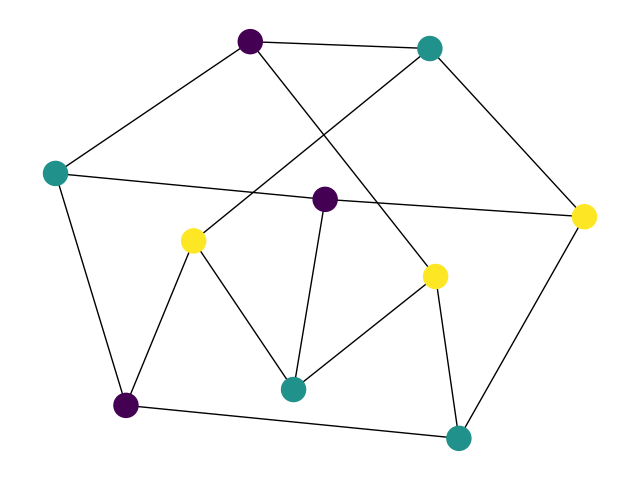

In [6]:
Pete = nx.petersen_graph()
draw_with_colors(Pete, greedy_color(Pete,range(10)),pos=nx.spring_layout(Pete, seed=1))

# Start of Degeneracy Stuff

Our next function takes as input a graph with *degeneracy at most 5* and **returns an order that witnesses this**.  We don't explicitly test the input to ensure it satisfies this property.  But if our algorithm succeeds, then it does.  And if our algorithm fails, then it does not. It simply returns ```Order``` which is a vertex order witnessing that the input graph has degeneracy at most 5.

In [7]:
def degeneracy_order_planar5(G0):   
    G = G0.copy()                                # avoid destroying the input graph
    Low_Degree = set()                           # initial empty set of low degree vertices
    for v in G.nodes:                            # initially populate set of low degree vertices 
        if G.degree[v] <= 5:                 
            Low_Degree.add(v)

    Order = []
    while G.nodes:                               # while Low_Degree: should work, but while G.nodes is more defensive
        if not Low_Degree:
            raise ValueError("This algorithm assumes the graph is 5-degenerate, but the given input graph is not.")
        v = Low_Degree.pop()
        Order.append(v)
        #Order.append((v,list(G.neighbors(v))))  # Use this version if we want to also store the nbrs at the time v is deleted

        for w in G.neighbors(v):
            if G.degree[w] <= 6:                 # haven't deleted v yet  
                     Low_Degree.add(w)
        G.remove_node(v)
        
    return Order 

The previous function is largely subsumed by the next one.  For any input graph, it computes the degeneracy.  It returns a pair ```d, Order```; here ```Order``` is the same as above, and ```d``` is the degeneracy of the graph.

In [38]:
def degeneracy_order(G0):
    G = G0.copy()                                   # we're going to destroy the graph, but don't want to affect the input
    max_so_far = 0                                  # this will ultimately be the degeneracy of G
                                                    #    we increase max_so_far each time we can't find any vertices of at most that degree
    Low_Degree = set()                              # initial empty set of low degree vertices
    Order = []

    while G.nodes:
        for v in G.nodes:                           # add to set of low degree vertices 
            if G.degree[v] <= max_so_far:        
                Low_Degree.add(v)
    
        while Low_Degree:                           
            v = Low_Degree.pop()
            Order.append(int(v))
            #Order.append((v,list(G.neighbors(v)))) # use this version if we want to also store the nbrs at the time v is deleted

            for w in G.neighbors(v):
                if G.degree[w] <= max_so_far+1:     # haven't deleted v yet  
                     Low_Degree.add(w)
            G.remove_node(v)
            
        if G.nodes:
            max_so_far+=1                           # ran out of low degree vertices; increase the threshold, find more, keep going...
        
    return max_so_far, Order 

In [9]:
# num = 50
# points = np.random.rand(num, 2)  # unfiltered; filtered is below
# tri = Delaunay(points)

For testing algorithms on planar graphs, it is convenient to have some nice planar graphs to play with.  Below we pick 200 points in the 3x3 square, and then build the *Delaunay triangulation* on them.  To keep the picture looking a bit nicer, we filter requiring that each new point is not too close to (within distance d of) any of the earlier points.  The distance d can be adjusted.  But if we make it too big, then our rejection filter will get too demanding and we will never find all of the desired points (so the cell will hang).

In [13]:
num = 200
points = []

d = .1                      # min allowable distance from all other earlier points
while len(points) < num:
    p = 3*np.random.rand(2)
    if all(np.linalg.norm(p - q) >= d for q in points):
        points.append(p)

points = np.array(points)

tri = Delaunay(points)      # Delaunay is imported at the top of the notebook

In [14]:
#tri.simplices              # If we want to see all the triangular faces of the triangulation, this is how.

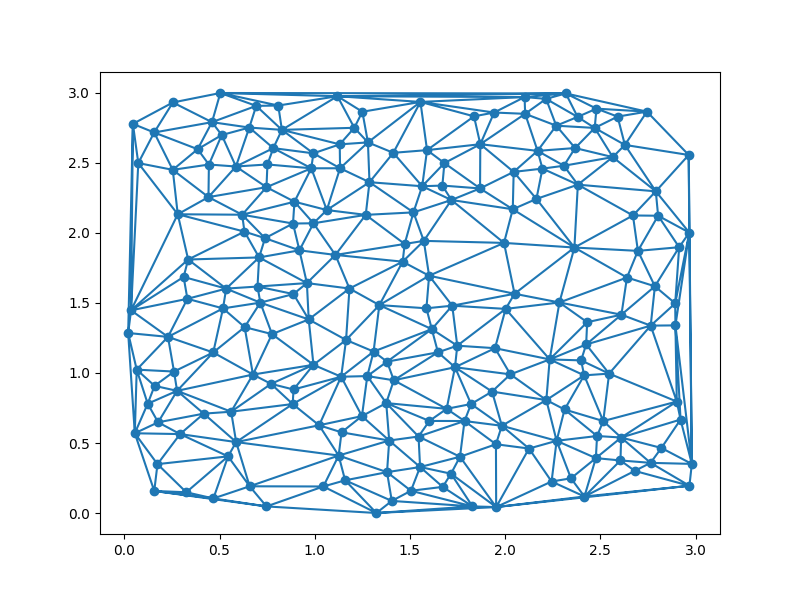

In [15]:
plt.close('all')                                            # close all old stuff on the canvas
plt.figure(figsize=(8,6))
plt.triplot(points[:, 0], points[:, 1], tri.simplices)      # plot each triangular face (from tri.simplices, not our graph Delaunay200 yet)
plt.scatter(points[:, 0], points[:, 1])                     # plot the actual vertices of the graph
plt.show()

Below we create a networkX graph G, give it num vertices (num is defined above), and then convert each triangular face into the set of its 3 composite edges.

In [33]:
G = nx.Graph()                           # new empty graph
G.add_nodes_from(range(num))             # add in all the vertices, starting from 0

for face in tri.simplices.tolist():      # tolist() converts from dtype np.int32 (which is an np dtpye) to int (which is a python dtype)
    G.add_edges_from([                   # for each face add in its 3 incident edges
        (face[0], face[1]),
        (face[0], face[2]),
        (face[1], face[2])
    ])
D200 = G.copy()                          # we will reuse the name G lots; this name is more likely to persist (and more evocative)

In [34]:
H = D200.copy()                 # so that we don't destroy D200 when we run degeneracy_order
d, D200_Order = degeneracy_order(H)
d, D200_Order

NameError: name 'degeneracy_order' is not defined

Now we draw the graph ```D200``` again, but with each vertex labeled with its index in the degeneracy order.

In [53]:
D200_Order_Dict = {}
for v in range(len(D200_Order)):
    D200_Order_Dict[D200_Order[v]] = v+1
#D200_Order_Dict

Now we will draw the graph D200 with ```nx.draw()```, rather than ```plt.triplot()``` and ```plt.scatter()``` as above.  So we need to actually associate the coordinates of each vertex with its name.  Then we can also label the appropriate vertices.

In [35]:
pos = {}                        
for v in range(len(points)):
    pos[v] = points[v]          # convert the point coordinates from an array into a dictionary

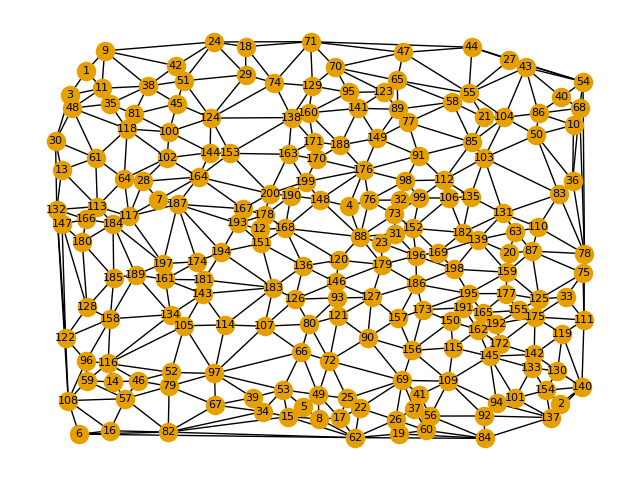

In [55]:
plt.close('all')
nx.draw(D200, labels=D200_Order_Dict, pos=pos, node_size=170, font_size=8, node_color = "#E69F00")
plt.show()

Now we want to use ```greedy_color``` to get a 6-coloring of the graph D200, and draw that graph using that coloring.  
(Actually, it will be a *5-coloring*, as long as D200 has *degeneracy 4*, which is typical.)

In [56]:
D200_Colors = greedy_color(D200, list(reversed(D200_Order)))    # returns a dictionary of the colors, indexed by vertex name
                                                                # D200_Order is the *degeneracy* order, so must be reversed for coloring
                                                                # but reversed() yields an iterator, which we must convert to a list

In [19]:
#D200_Colors

In [20]:
# for (v,w) in D200.edges():
#    print((v, w), D200_Colors[v],D200_Colors[w], D200_Colors[v]==D200_Colors[w])  # check for no monochromatic edges

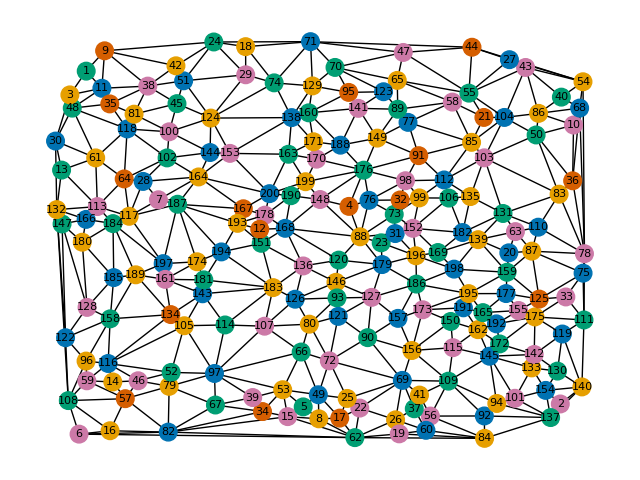

In [57]:
draw_with_colors(D200, Color_dict = D200_Colors, labels=D200_Order_Dict, pos=pos, node_size=160, cmap=cmap, font_size=8)

## More Examples

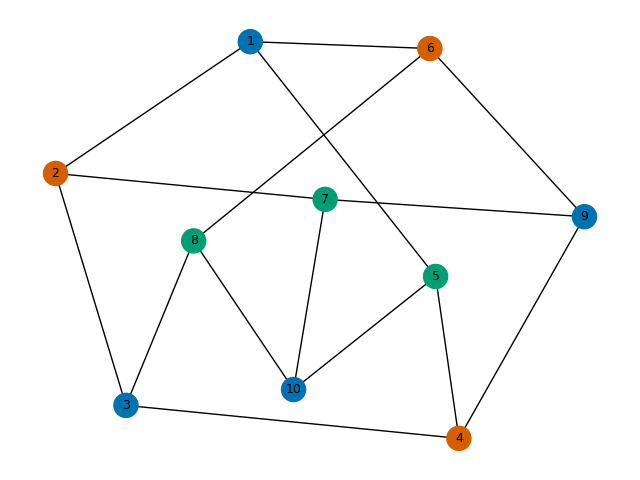

In [42]:
Pete = nx.petersen_graph()
d, Pete_order = degeneracy_order(Pete)
Pete_colors = greedy_color(Pete, list(reversed(Pete_order)))
Pete_order = {v: i for i, v in enumerate(Pete_order, start=1)}

draw_with_colors(Pete, Pete_colors, labels=Pete_order, cmap = cmap, font_size=9, pos=nx.spring_layout(Pete, seed=1))

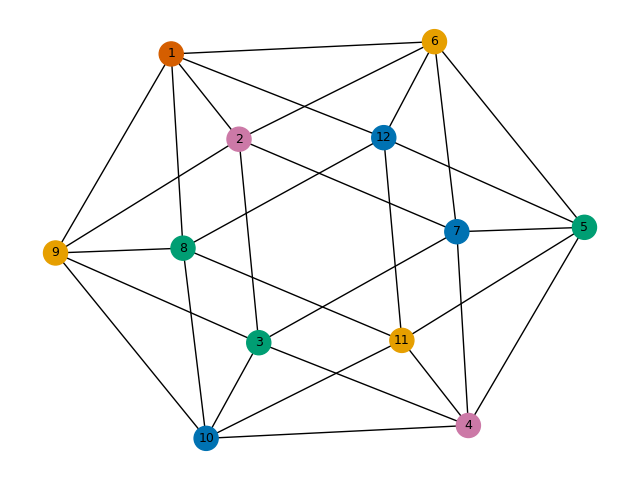

In [44]:
icos = nx.icosahedral_graph()
d, icos_order = degeneracy_order(icos)
icos_colors = greedy_color(icos, list(reversed(icos_order)))
icos_order = {v: i for i, v in enumerate(icos_order, start=1)}

draw_with_colors(icos, icos_colors, labels=icos_order, cmap = cmap, font_size=9, pos=nx.spring_layout(icos, seed=7))

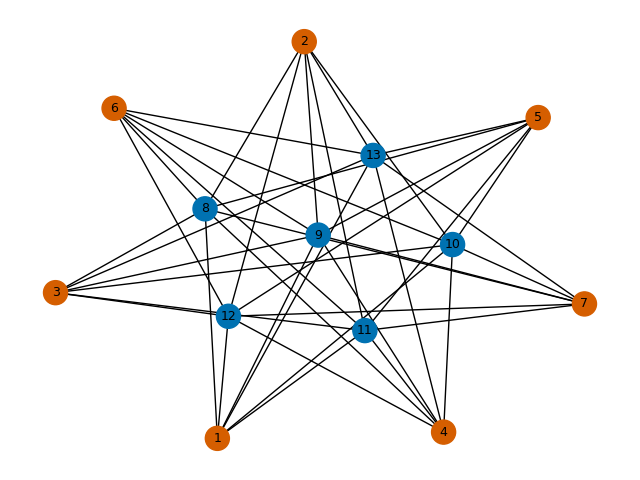

In [25]:
K67 = nx.complete_bipartite_graph(6,7)
d, K67_order = degeneracy_order(K67)
K67_colors = greedy_color(K67, list(reversed(K67_order)))
K67_order = {v: i for i, v in enumerate(K67_order, start=1)}

draw_with_colors(K67, K67_colors, labels=K67_order, cmap = cmap, font_size=9, pos=nx.spring_layout(K67, seed=7))

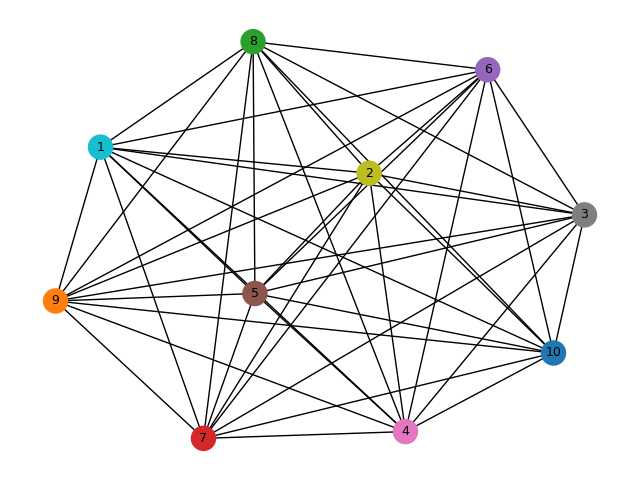

In [26]:
K10 = nx.complete_graph(10)
d, K10_order = degeneracy_order(K10)
K10_colors = greedy_color(K10, list(reversed(K10_order)))
K10_order = {v: i for i, v in enumerate(K10_order, start=1)}

draw_with_colors(K10, K10_colors, labels=K10_order, cmap = plt.cm.tab10, font_size=9, pos=nx.spring_layout(K10, seed=7))

## Still want to add another Delaunay triangulation

# 5-Coloring Algorithm for Planar Graphs

This section still *needs work*.

In [138]:
def contraction_order_planar(G0):
    G = G0.copy()                            # So we don't destroy the input graph
    Low_Degree = set()                       # initial empty set of low degree vertices
    for v in G.nodes:                        # initially populate set of low degree vertices 
        if G.degree[v] <= 5:                 
            Low_Degree.add(v)
            #print("Added", v, "to Low_Degree")

    Order = []
    while G.nodes:                           
        if not Low_Degree:
            raise ValueError("The graph should have 5^--vertices, but doesn't.  Why not?!")
        v = Low_Degree.pop()
        #print("Removed", v, "from Low_Degree")

        Nv = set(G.neighbors(v))

        if G.degree(v) <= 3:                 # v is 3^--vertex
            Order.append((v, Nv))

            for w in set(G.neighbors(v)):        
                if G.degree[w] <= 6:         # we will delete v in this case, so threshold increases to 6.
                     Low_Degree.add(w)
            G.remove_node(v)
            
            
        else:                                # v has degree 4 or 5
                
            # find 2 neighbors of v that are non-adjacent
            # call them w, x
            pair_found = False
            for w, x in combinations(Nv, 2):           # consider all pairs w,x of neighbors of v
                #print (v,":", w, x, (w,x) in G.edges)
                if (w,x) not in G.edges:
                    pair_found = True
                    break
            if not pair_found:
                raise ValueError("Didn't find a pair of non-adjacent neighbors! Why?!")
                
        
            Nw = set(G.neighbors(w)) 
            Nx = set(G.neighbors(x))

            Order.append((v, Nv, (w,x), (Nw,Nx) ))
        
            G.remove_nodes_from([v,w,x])               # don't need to delete incident edges; they get deleted automatically with vertices
            G.add_node(v)                              # deleting then adding removes all incident edges
        
            Nnew = (set(Nw) | set(Nx)) - {v}           # | is union
            for y in Nnew:
                G.add_edge(v,y)
        
            Low_Degree.difference_update([w,x])        # this removes w, x from Low_Degree, but doesn't complain if one/two isn't there
                                                       # w and x are gone from the graph, and v is already gone, due to v = Low_Degree.pop()
        
            for w in set(G.neighbors(v)) | {v}:        # but (new) v might also have degree low now
                if G.degree[w] <= 5:                   # (unlike for degeneracy) we don't delete v (in this case), so threshold stays at 5.
                     Low_Degree.add(w)
                     #print("Added", w, "to Low_Degree")
        
    return Order 

In [54]:
palette = set(range(10))
list_of_5lists  = list(combinations(palette, 5))
random_fives = {v: random.choice(list_of_5lists) for v in G.nodes}

In [55]:
random_fives

{0: (1, 2, 4, 6, 8),
 1: (0, 1, 3, 4, 9),
 2: (1, 2, 5, 6, 8),
 3: (0, 1, 2, 3, 6),
 4: (2, 6, 7, 8, 9),
 5: (0, 4, 5, 6, 7),
 6: (2, 5, 7, 8, 9),
 7: (0, 1, 2, 5, 7),
 8: (1, 4, 6, 7, 8),
 9: (0, 2, 4, 5, 7),
 10: (0, 2, 5, 6, 7),
 11: (1, 3, 4, 6, 7),
 12: (0, 1, 2, 4, 7),
 13: (1, 2, 3, 4, 9),
 14: (0, 2, 6, 7, 9),
 15: (2, 3, 5, 6, 8),
 16: (1, 3, 4, 6, 7),
 17: (4, 5, 6, 7, 8),
 18: (2, 3, 4, 7, 9),
 19: (0, 3, 4, 8, 9),
 20: (0, 3, 5, 6, 7),
 21: (0, 1, 3, 5, 7),
 22: (2, 4, 7, 8, 9),
 23: (0, 4, 5, 6, 9),
 24: (0, 3, 4, 7, 9),
 25: (2, 4, 6, 8, 9),
 26: (0, 3, 4, 5, 9),
 27: (1, 2, 4, 6, 7),
 28: (0, 3, 4, 5, 8),
 29: (1, 2, 6, 8, 9),
 30: (1, 3, 5, 7, 8),
 31: (0, 2, 5, 7, 8),
 32: (1, 2, 4, 5, 7),
 33: (2, 5, 6, 7, 8),
 34: (1, 2, 5, 6, 8),
 35: (2, 5, 6, 7, 8),
 36: (0, 3, 4, 8, 9),
 37: (1, 2, 4, 7, 8),
 38: (0, 1, 2, 4, 6),
 39: (0, 1, 4, 7, 8),
 40: (2, 3, 4, 5, 6),
 41: (1, 2, 4, 5, 6),
 42: (0, 5, 6, 7, 8),
 43: (0, 3, 4, 5, 6),
 44: (0, 1, 2, 3, 4),
 45: (0, 5, 6, 8, 9)

In [48]:
?list_family

Type:        set
String form: {(0, 2, 3, 6, 8), (0, 1, 2, 8, 9), (1, 2, 4, 5, 8), (0, 1, 3, 5, 7), (1, 3, 4, 5, 9), (0, 4, 5, 8 <...> 1, 2, 7, 8), (1, 4, 6, 7, 8), (1, 2, 6, 7, 8), (0, 4, 5, 6, 9), (2, 3, 5, 6, 8), (1, 2, 3, 6, 7)}
Length:      252
Docstring:   Build an unordered collection of unique elements.

In [28]:
icos = nx.icosahedral_graph()

In [149]:
icos_order = contraction_order_planar(icos)
icos_order

[(0, {1, 5, 7, 8, 11}, (1, 7), ({0, 2, 5, 6, 8}, {0, 8, 9, 10, 11})),
 (2, {0, 3, 6, 8, 9}, (0, 3), ({2, 5, 6, 8, 9, 10, 11}, {2, 4, 6, 9, 10})),
 (4, {2, 5, 6, 10, 11}, (5, 10), ({2, 4, 6, 11}, {2, 4, 9, 11})),
 (6, {2, 4}),
 (8, {2, 9}),
 (9, {2, 4}),
 (11, {2, 4}),
 (2, {4}),
 (4, set())]

In [151]:
num1 = sum(len(x)==2 for x in icos_order)
num2 = sum(len(x)==4 for x in icos_order)
print(num1,"deletions; and",num2,"contractions")
assert num1+2*num2 == len(icos)

6 deletions; and 3 contractions


In [144]:
D200_order = contraction_order_planar(D200)
D200_order

[(1,
  {2, 19, 34, 107, 194},
  (2, 34),
  ({1, 11, 19, 92, 194}, {1, 19, 41, 106, 107, 122})),
 (3, {40, 148, 164}),
 (4,
  {8, 25, 89, 111, 177},
  (8, 111),
  ({4, 13, 36, 86, 89, 177}, {4, 25, 40, 89, 102, 128, 164})),
 (5,
  {48, 76, 135, 185, 187},
  (135, 48),
  ({5, 64, 76, 152, 185, 195}, {5, 43, 76, 125, 187})),
 (11,
  {1, 62, 92, 115, 194},
  (1, 115),
  ({11, 19, 41, 92, 106, 107, 122, 194}, {11, 62, 71, 124, 186, 194})),
 (17,
  {30, 68, 96, 120},
  (120, 30),
  ({17, 65, 68, 69, 94, 96, 149, 162, 168},
   {7, 17, 21, 64, 68, 96, 97, 127, 136})),
 (18,
  {14, 55, 82, 141, 157},
  (141, 82),
  ({10, 14, 18, 110, 136, 157, 199}, {18, 55, 84, 103, 157, 172})),
 (21,
  {10, 17, 64, 136, 152},
  (64, 136),
  ({5, 17, 21, 76, 97, 152}, {10, 17, 18, 21, 96, 199})),
 (22,
  {44, 90, 108, 123, 196},
  (196, 108),
  ({22, 44, 46, 57, 59, 123, 131}, {9, 22, 44, 65, 90, 94, 143})),
 (25,
  {4, 70, 85, 128, 177},
  (128, 177),
  ({4, 25, 70, 164}, {4, 25, 66, 85, 86, 110, 195})),
 (26

In [152]:
num1 = sum(len(x)==2 for x in D200_order)
num2 = sum(len(x)==4 for x in D200_order)
print(num1,"deletions; and",num2,"contractions")
assert num1+2*num2 == len(D200)

48 deletions; and 76 contractions


In [72]:
#Order

In [154]:
def color_from_planar_order(Order0):
    Order = Order0.copy()
    Colors = {}                                          # just an empty dictionary
    while Order:
        update = Order.pop()
        #print(update)

        if len(update) == 2:
            v, nbrs = update

        elif len(update) == 4:
            v, nbrs, (w,x), (Nw, Nx) = update            # don't currently actually need (Nw, Nx); but we'll keep them in case...
            Colors[w] = Colors[v]
            Colors[x] = Colors[v]

        else:
            raise ValueError("Update had length other than 2 or 4.  Why?!")

        #print("Colors:", Colors)
        #print("nbrs:", nbrs)
        Used_colors = {Colors[y] for y in nbrs}          # set of all colors forbidden on v
        my_color = 1
        while my_color in Used_colors:                   # find first color not in Used_colors
            my_color += 1
        Colors[v] = my_color

    return Colors

In [142]:
D200_colors = color_from_planar_order(D200_order)
D200_colors

{63: 3,
 14: 1,
 119: 3,
 147: 3,
 127: 1,
 61: 3,
 53: 1,
 162: 3,
 31: 4,
 157: 2,
 23: 2,
 36: 3,
 84: 5,
 134: 4,
 25: 4,
 139: 5,
 129: 3,
 123: 3,
 93: 1,
 87: 3,
 62: 4,
 122: 1,
 190: 3,
 188: 2,
 185: 4,
 154: 3,
 29: 1,
 47: 3,
 42: 2,
 86: 5,
 156: 3,
 140: 5,
 40: 3,
 152: 2,
 60: 1,
 38: 5,
 81: 5,
 18: 3,
 12: 2,
 11: 3,
 10: 3,
 9: 1,
 194: 4,
 118: 3,
 191: 3,
 189: 3,
 56: 2,
 20: 4,
 52: 4,
 187: 2,
 184: 4,
 181: 2,
 179: 1,
 176: 2,
 175: 4,
 169: 3,
 168: 4,
 182: 4,
 159: 3,
 172: 3,
 199: 3,
 91: 4,
 83: 4,
 96: 4,
 195: 1,
 151: 2,
 80: 1,
 27: 5,
 145: 2,
 144: 3,
 143: 3,
 178: 2,
 155: 2,
 43: 1,
 121: 3,
 138: 4,
 130: 5,
 37: 1,
 133: 2,
 163: 1,
 45: 1,
 171: 2,
 54: 2,
 105: 3,
 77: 2,
 68: 1,
 76: 4,
 125: 2,
 124: 1,
 117: 4,
 69: 4,
 41: 5,
 26: 2,
 160: 4,
 114: 4,
 58: 1,
 126: 1,
 100: 3,
 46: 5,
 78: 1,
 180: 2,
 116: 3,
 113: 3,
 104: 4,
 15: 1,
 166: 1,
 198: 1,
 193: 4,
 158: 4,
 98: 2,
 21: 4,
 149: 1,
 95: 3,
 94: 1,
 49: 5,
 28: 1,
 89: 4,
 8

In [157]:
assert set(D200_colors)==set(D200.nodes)

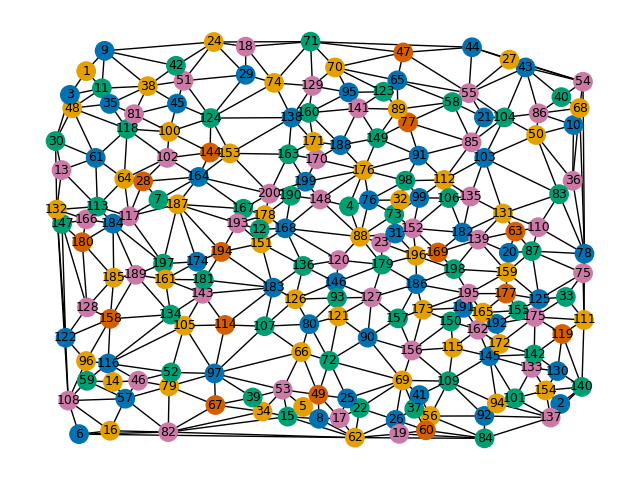

In [186]:
draw_with_colors(D200, Color_dict = D200_colors, labels=D200_Order_Dict, cmap = cmap, font_size=9, pos=pos, node_size=175)

In [196]:
?D200

Type:           Graph
String form:    Graph with 200 nodes and 580 edges
Length:         200
File:           ~/Desktop/all/python/dan_python_env/lib/python3.14/site-packages/networkx/classes/graph.py
Docstring:     
Base class for undirected graphs.

A Graph stores nodes and edges with optional data, or attributes.

Graphs hold undirected edges.  Self loops are allowed but multiple
(parallel) edges are not.

Nodes can be arbitrary (hashable) Python objects with optional
key/value attributes, except that `None` is not allowed as a node.

Edges are represented as links between nodes with optional
key/value attributes.

Parameters
----------
incoming_graph_data : input graph (optional, default: None)
    Data to initialize graph. If None (default) an empty
    graph is created.  The data can be any format that is supported
    by the to_networkx_graph() function, currently including edge list,
    dict of dicts, dict of lists, NetworkX graph, 2D NumPy array, SciPy
    sparse matrix, or Py

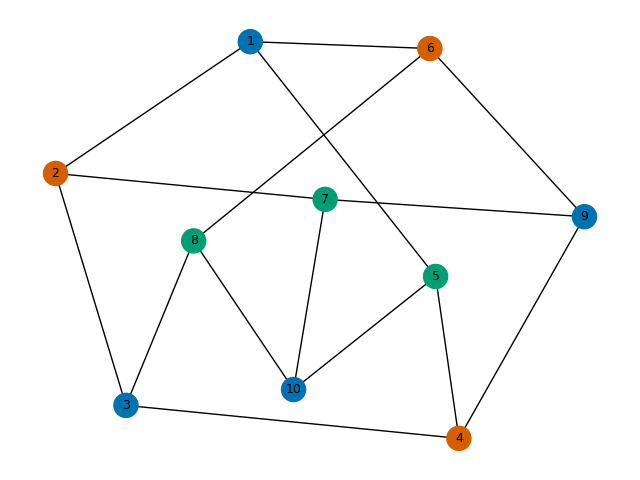

In [145]:
Pete = nx.petersen_graph()
Pete_order = contraction_order_planar(Pete)                # this is backwards, but it gets reversed by pop()
Pete_colors = color_from_planar_order(Pete_order)
#Pete_colors
Pete_order2 = {v: i for i, v in enumerate(list(range(10)), start=1)}
#Pete_order
draw_with_colors(Pete, Pete_colors, labels=Pete_order2, cmap = cmap, font_size=9, pos=nx.spring_layout(Pete, seed=1))

In [135]:
icos = nx.icosahedral_graph()
icos_order = contraction_order_planar(icos)
icos_order

[(0, {1, 5, 7, 8, 11}, (1, 7), ({0, 2, 5, 6, 8}, {0, 8, 9, 10, 11})),
 (2, {0, 3, 6, 8, 9}, (0, 3), ({2, 5, 6, 8, 9, 10, 11}, {2, 4, 6, 9, 10})),
 (4, {2, 5, 6, 10, 11}, (5, 10), ({2, 4, 6, 11}, {2, 4, 9, 11})),
 (6, {2, 4}),
 (8, {2, 9}),
 (9, {2, 4}),
 (11, {2, 4}),
 (2, {4}),
 (4, set())]

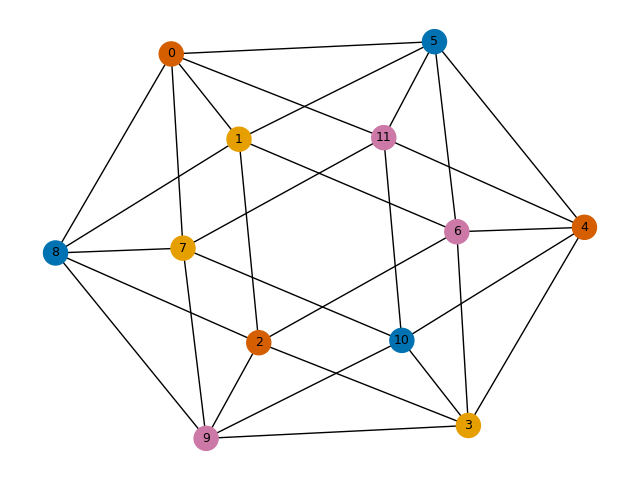

In [137]:
icos_colors = color_from_planar_order(icos_order)
icos_order2 = {v: i for i, v in enumerate(range(12), start=0)}

draw_with_colors(icos, icos_colors, labels=icos_order2, cmap = cmap, font_size=9, pos=nx.spring_layout(icos, seed=7))

## Some testing for larger examples (that we won't draw)

In [160]:
num = 50000
points = np.random.rand(num, 2)  # unfiltered 
tri = Delaunay(points)

In [161]:
G = nx.Graph()
G.add_nodes_from(range(num))

for face in tri.simplices.tolist():
    G.add_edges_from([
        (face[0], face[1]),
        (face[0], face[2]),
        (face[1], face[2])
    ])

Order = contraction_order_planar(G)

num1 = sum(len(update) == 2 for update in Order)
num2 = sum(len(update) == 4 for update in Order)

assert num1 + 2*num2 == len(G)

Colors = color_from_planar_order(Order)

assert set(Colors) == set(G.nodes)
assert len(set(Colors.values())) <= 5
assert all(Colors[u] != Colors[v] for u, v in G.edges)

In [179]:
timing = []
for n in [1000, 5000, 10000, 50000, 100000, 200000, 500000]:
    # construct G with n vertices ...

    for i in range(5):
        start = time.perf_counter()
        points = np.random.rand(n, 2)  # unfiltered 
        tri = Delaunay(points)
        elapsed1 = time.perf_counter() - start

        print(f"{n:6d} vertices: {elapsed1:.3f} seconds (to build)")

        start = time.perf_counter()
        G = nx.Graph()
        G.add_nodes_from(range(n))
    
        for face in tri.simplices.tolist():
            G.add_edges_from([
                (face[0], face[1]),
                (face[0], face[2]),
                (face[1], face[2])
            ])
        elapsed2 = time.perf_counter() - start

        print(f"{n:6d} vertices: {elapsed2:.3f} seconds (to remix)")
    
        start = time.perf_counter()
        Order = contraction_order_planar(G)
        elapsed3 = time.perf_counter() - start

        num1 = sum(len(update) == 2 for update in Order)
        num2 = sum(len(update) == 4 for update in Order)
    
        print(f"{n:6d} vertices: {elapsed3:.3f} seconds (to order)")
        assert num1 + 2*num2 == len(G)
    
        start = time.perf_counter()
        Colors = color_from_planar_order(Order)
        elapsed4 = time.perf_counter() - start

        print(f"{n:6d} vertices: {elapsed4:.3f} seconds (to color)")
    
        start = time.perf_counter()
        assert set(Colors) == set(G.nodes)
        assert len(set(Colors.values())) <= 5
        assert all(Colors[u] != Colors[v] for u, v in G.edges)
        elapsed5 = time.perf_counter() - start

        print(f"{n:6d} vertices: {elapsed5:.3f} seconds (to check)")
        timing.append((n,elapsed1,elapsed2,elapsed3,elapsed4,elapsed5))

  1000 vertices: 0.006 seconds (to build)
  1000 vertices: 0.013 seconds (to remix)
  1000 vertices: 0.015 seconds (to order)
  1000 vertices: 0.000 seconds (to color)
  1000 vertices: 0.001 seconds (to check)
  1000 vertices: 0.002 seconds (to build)
  1000 vertices: 0.006 seconds (to remix)
  1000 vertices: 0.012 seconds (to order)
  1000 vertices: 0.000 seconds (to color)
  1000 vertices: 0.001 seconds (to check)
  1000 vertices: 0.002 seconds (to build)
  1000 vertices: 0.005 seconds (to remix)
  1000 vertices: 0.012 seconds (to order)
  1000 vertices: 0.000 seconds (to color)
  1000 vertices: 0.001 seconds (to check)
  1000 vertices: 0.002 seconds (to build)
  1000 vertices: 0.005 seconds (to remix)
  1000 vertices: 0.011 seconds (to order)
  1000 vertices: 0.000 seconds (to color)
  1000 vertices: 0.001 seconds (to check)
  1000 vertices: 0.002 seconds (to build)
  1000 vertices: 0.005 seconds (to remix)
  1000 vertices: 0.011 seconds (to order)
  1000 vertices: 0.000 seconds (to

In [191]:
timing

[(1000,
  0.005747374962083995,
  0.013430959079414606,
  0.01528829091694206,
  0.0004338329890742898,
  0.0009164579678326845),
 (1000,
  0.0023480000672861934,
  0.005771625088527799,
  0.011991000035777688,
  0.0003366670571267605,
  0.0007171250181272626),
 (1000,
  0.0018319590017199516,
  0.004894625046290457,
  0.011587167042307556,
  0.0003353329375386238,
  0.0007706249598413706),
 (1000,
  0.0019592090975493193,
  0.004710374982096255,
  0.010594499995931983,
  0.0003553329734131694,
  0.0006912910612300038),
 (1000,
  0.0017182499868795276,
  0.004830749938264489,
  0.010761082987301052,
  0.00032424996607005596,
  0.0006793340435251594),
 (5000,
  0.009503833018243313,
  0.11510554200503975,
  0.05799704103264958,
  0.00180974998511374,
  0.004392958013340831),
 (5000,
  0.009030417073518038,
  1.1961193330353126,
  0.05228966707363725,
  0.0017909579910337925,
  0.0038812910206615925),
 (5000,
  0.00860250007826835,
  0.023228124948218465,
  0.04983799997717142,
  0.00153

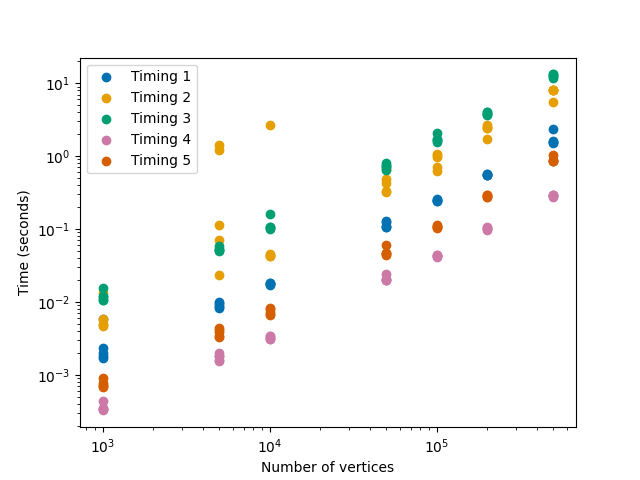

In [185]:
plt.close('all')
for i in range(1, 6):
    plt.scatter(
        [row[0] for row in timing],
        [row[i] for row in timing],
        color=cmap((i - 1) / 4),
        label=f'Timing {i}'
    )


plt.xscale('log')
plt.yscale('log')

plt.xlabel('Number of vertices')
plt.ylabel('Time (seconds)')
plt.legend()
plt.show()

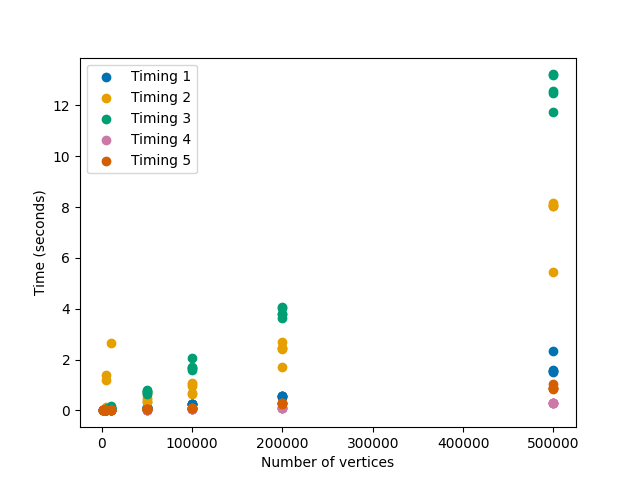

In [187]:
plt.close('all')
for i in range(1, 6):
    plt.scatter(
        [row[0] for row in timing],
        [row[i] for row in timing],
        color=cmap((i - 1) / 4),
        label=f'Timing {i}'
    )


#plt.xscale('log')
#plt.yscale('log')

plt.xlabel('Number of vertices')
plt.ylabel('Time (seconds)')
plt.legend()
plt.show()

In [192]:
timing = np.array(timing)

In [195]:
for i in range(1,6):
    result = linregress(np.log(timing[:, 0]), np.log(timing[:, i]))
    print("Regression for (logs) in stage", i)
    print(result)

Regression for (logs) in stage 1
LinregressResult(slope=np.float64(1.071482764779632), intercept=np.float64(-13.691676229650831), rvalue=np.float64(0.9940424997864932), pvalue=np.float64(2.3769187859388704e-33), stderr=np.float64(0.02045137468172826), intercept_stderr=np.float64(0.2153146020745049))
Regression for (logs) in stage 2
LinregressResult(slope=np.float64(1.0110259816825988), intercept=np.float64(-11.463196084982968), rvalue=np.float64(0.8901299464888933), pvalue=np.float64(8.382324764423205e-13), stderr=np.float64(0.09010262294620576), intercept_stderr=np.float64(0.9486115582667523))
Regression for (logs) in stage 3
LinregressResult(slope=np.float64(1.130216382090443), intercept=np.float64(-12.449727205476007), rvalue=np.float64(0.9975441245238589), pvalue=np.float64(1.0889179565273316e-39), stderr=np.float64(0.01381414069409237), intercept_stderr=np.float64(0.14543698175981834))
Regression for (logs) in stage 4
LinregressResult(slope=np.float64(1.0845769764620652), intercep

# Thomassen's 5-Choosability Proof for Planar Graphs

### Some useful nx functionality for working with planar embeddings
```is_planar, embedding = nx.check_planarity(G)``` <br>
```embedding.neighbor_cw_order(v, w)``` <br>
```embedding.neighbor_ccw_order(v, w)``` <br>
```embedding.traverse_face(v, w)``` <br>

### and a bit for lists 
```Low_Degree.difference_update([w,x])``` # removes w,x from Low_Degree, but doesn't complain if one/both absent<br>
```A | B``` # gives *union* of sets A and B<br>
```A & B``` # gives *intersection* of sets A and B<br>
```A - B``` # gives A setminus B<br>
```A ^ B``` # gives symmetric difference

In [147]:
def thomassen_coloring(
    G: nx.Graph, 
    lists0: dict
) -> dict:
    # copy L to lists
    lists = {v: L.copy() for v, L in lists0.items()}   # to protect the input, since alg below will restrict the lists   
    assert all(len(L) >= 5 for v, L in lists.items())  # check that each list has size at least 5
    
    # get embedding from networkX
    is_planar, embedding = nx.check_planarity(G)
    assert is_planar  # check that G really has a planar embedding
    
    # find 4^+-face f in embedding (assume G is near-triangulation, so only one such f exists)
    long_faces = []
    seen = set()  # so we don't re-traverse faces we've already seen 
    
    for v, w in embedding.edges:
        if (v, w) not in seen:
            temp = embedding.traverse_face(v, w, mark_half_edges=seen)
            if len(temp) >= 4:
                long_faces.append(temp)
                
    assert len(long_faces) <= 1
    v, w = next(iter(embedding.edges))
    C = long_faces[0] if long_faces else embedding.traverse_face(v, w)
    #print("C is:", C)
    
    
    # get directed boundary cycle \vec{C} of f (with G on the *right* of \vec{C})
    C = list(reversed(C))  # want the outer face (f) on the *left* of C, not the right
    # specify v1, v2 as first on \vec{C}
    v1 = C[0]
    v2 = C[1]
    #print("C is:", C)
    #print("embedding.traverse_face(",v1,",",v2,") is:", set(embedding.traverse_face(v1, v2)))
    
    # reduce lists for v1, v2 (don't touch other lists)
    lists[v1] = {lists[v1].pop()}                # restrict L(v1) to a singleton
    #print("Color for", v1, "is", lists[v1])
    lists[v2].difference_update(lists[v1])       # remove L(v1), now a singleton, from L(v2)
    lists[v2] = {lists[v2].pop()}                # restrict L(v2) to a singleton
    #print("Color for", v2, "is", lists[v2])

    #print("Starting recursion with C as:", C)
    thomassen(G, embedding, C, lists)

    coloring = {v: L.pop() for v, L in lists.items()}     # convert (singleton) lists to dictionary of coloring
    assert all(coloring[v] in lists0[v] for v in G.nodes)  # double check that every vertex is really colored from *its* list
    return coloring
      

In [150]:
def thomassen(
    G: nx.Graph, 
    embedding: nx.PlanarEmbedding, 
    C: list, 
    lists: dict
) -> None:
    #print("C is:", C)
    base_case = len(C) == 3  # C is short
    if base_case:
        v1, v2, v3 = C
        #print("C has length 3.")
        
    if base_case and set(embedding.traverse_face(v1, v2)) == {v1, v2, v3}:  # and C also has no verts in its interior  
        # base case of recursion; get color for v3 and return
        # print("C has empty interior.")
        lists[v3].difference_update(lists[v1] | lists[v2])  # discard from L(v3) both L(v1) and L(v2)
        lists[v3] = {lists[v3].pop()}  # actually pick a single color for v3
        #print("Color for", v3, "is", lists[v3])
        return
            
    else:
        # check for chords incident with vn; if such a chord exists (could be many), pick an arbitrary one; call its other endpoint vi
        #print("C has length at least 4, or C has nonempty interior.")
        vnm1, vn = C[-2:]
        v1 = C[0]
        chords = (set(C) & set(G.neighbors(vn))) - {v1, vnm1}
        vi = chords.pop() if chords else None
        #if vi:
        #    print("vi is:", vi)
        #else:
        #    print("no chord")
                           

        if vi is None:  # chord does not exist:
            x = embedding.traverse_face(vn,v1)[2]
            # use traverse_neighbors_cw(vn) and x to find P and update C (call it Cnew)
            nbr_cycle = list(embedding.neighbors_cw_order(vn))
            nbr_cycle = nbr_cycle if nbr_cycle.index(x) == ((nbr_cycle.index(v1)+1)%len(nbr_cycle)) else list(reversed(nbr_cycle))
            assert nbr_cycle.index(x) == ((nbr_cycle.index(v1)+1)%len(nbr_cycle))  # check that nbr_cycle looks like we want it to
            a = nbr_cycle.index(v1)
            b = nbr_cycle.index(vnm1)
            # get the (directed) path of nbr_cycle running from v1 to vnm1, excluding both vertices
            P = nbr_cycle[a+1:b] if b > a else nbr_cycle[a+1:] + nbr_cycle[0:b]
            #print("P is:", P)
            Cnew = C[:-1] + list(reversed(P))
            #print("Cnew is:", Cnew)

            # pick 2 safe colors {c1, c2} for vn
            lists[vn].difference_update(lists[v1])
            c1 = lists[vn].pop()
            c2 = lists[vn].pop()
            safe = {c1, c2}
            lists[vn] = safe
            #print("Saved colors", safe,"for vertex", vn)
            # remove c1, c2 from L(w) for all w in P\setminus {v1, v{n-1}}
            for w in P:
                lists[w].difference_update(safe)
                #print("Discarding colors", safe, "for vertex", w)

            #print("Recursing with Cnew as:", Cnew)
            thomassen(G, embedding, Cnew, lists)
            assert all(len(lists[v])==1 for v in Cnew)
            lnew = len(Cnew)
            assert all(lists[Cnew[i]] != lists[Cnew[(i+1)% lnew]] for i in range(lnew))
            bad_edges = [(v, w) for v, w in G.edges if
                         lists[v] == lists[w] and
                         len(lists[v]) == 1]
            assert not bad_edges, bad_edges
        
            
            # color vn from {c1,c2} \setminus L(vnm1)
            lists[vn].difference_update(lists[vnm1])
            #print("Trying to pick color for", vn)
            lists[vn] = {lists[vn].pop()}  # actually choose a color for vn
            #print("Color for", vn, "is", lists[vn])

        else:  # chord exists
            i = C.index(vi)
            C1 = C[:i+1] + [vn]
            C2 = [vn] + C[i:-1]

            #print("Recursing with C1 as:", C1)
            thomassen(G, embedding, C1, lists)
            assert all(len(lists[v])==1 for v in C1)
            l1 = len(C1)
            assert all(lists[C1[i]] != lists[C1[(i+1)% l1]] for i in range(l1))
            bad_edges = [(v, w) for v, w in G.edges if
                         lists[v] == lists[w] and
                         len(lists[v]) == 1]
            assert not bad_edges, bad_edges
        
            #print("Recursing with C2 as:", C2)
            thomassen(G, embedding, C2, lists)
            assert all(len(lists[v])==1 for v in C2)
            l2 = len(C2)
            assert all(lists[C2[i]] != lists[C2[(i+1)% l2]] for i in range(l2))
            bad_edges = [(v, w) for v, w in G.edges if
                         lists[v] == lists[w] and
                         len(lists[v]) == 1]
            assert not bad_edges, bad_edges

In [151]:
#icos = nx.icosahedral_graph()
all_fives = {v: {1,2,3,4,5} for v in D200.nodes}

In [152]:
all_fives

{0: {1, 2, 3, 4, 5},
 1: {1, 2, 3, 4, 5},
 2: {1, 2, 3, 4, 5},
 3: {1, 2, 3, 4, 5},
 4: {1, 2, 3, 4, 5},
 5: {1, 2, 3, 4, 5},
 6: {1, 2, 3, 4, 5},
 7: {1, 2, 3, 4, 5},
 8: {1, 2, 3, 4, 5},
 9: {1, 2, 3, 4, 5},
 10: {1, 2, 3, 4, 5},
 11: {1, 2, 3, 4, 5},
 12: {1, 2, 3, 4, 5},
 13: {1, 2, 3, 4, 5},
 14: {1, 2, 3, 4, 5},
 15: {1, 2, 3, 4, 5},
 16: {1, 2, 3, 4, 5},
 17: {1, 2, 3, 4, 5},
 18: {1, 2, 3, 4, 5},
 19: {1, 2, 3, 4, 5},
 20: {1, 2, 3, 4, 5},
 21: {1, 2, 3, 4, 5},
 22: {1, 2, 3, 4, 5},
 23: {1, 2, 3, 4, 5},
 24: {1, 2, 3, 4, 5},
 25: {1, 2, 3, 4, 5},
 26: {1, 2, 3, 4, 5},
 27: {1, 2, 3, 4, 5},
 28: {1, 2, 3, 4, 5},
 29: {1, 2, 3, 4, 5},
 30: {1, 2, 3, 4, 5},
 31: {1, 2, 3, 4, 5},
 32: {1, 2, 3, 4, 5},
 33: {1, 2, 3, 4, 5},
 34: {1, 2, 3, 4, 5},
 35: {1, 2, 3, 4, 5},
 36: {1, 2, 3, 4, 5},
 37: {1, 2, 3, 4, 5},
 38: {1, 2, 3, 4, 5},
 39: {1, 2, 3, 4, 5},
 40: {1, 2, 3, 4, 5},
 41: {1, 2, 3, 4, 5},
 42: {1, 2, 3, 4, 5},
 43: {1, 2, 3, 4, 5},
 44: {1, 2, 3, 4, 5},
 45: {1, 2, 3, 4, 5}

In [74]:
D200_colors = thomassen_coloring(D200, all_fives)

In [8]:
icos_colors

{0: 3, 1: 1, 2: 4, 3: 5, 4: 1, 5: 5, 7: 1, 8: 2, 9: 3, 10: 2, 11: 4, 6: 2}

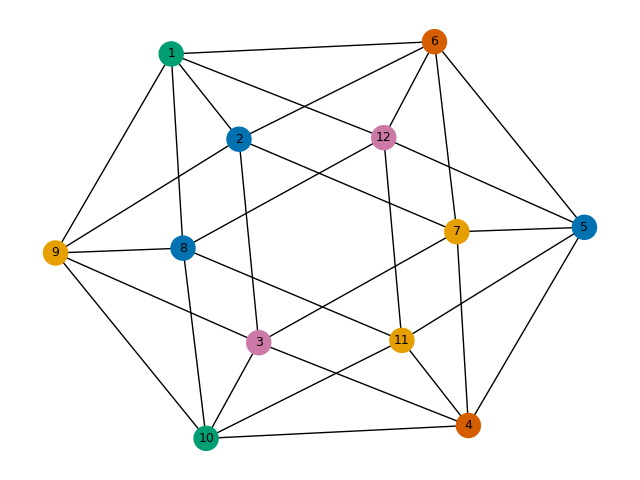

In [12]:
icos_order = {v: i for i, v in enumerate(range(12), start=1)}

draw_with_colors(icos, icos_colors, labels=icos_order, cmap = cmap, font_size=9, pos=nx.spring_layout(icos, seed=7))

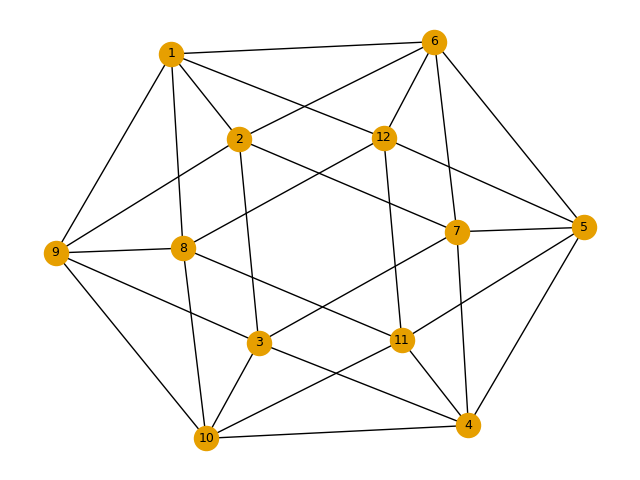

In [10]:
icos_order = {v: i for i, v in enumerate(range(12), start=1)}
plt.close('all')
nx.draw(icos, labels=icos_order, font_size=9, node_color = "#E69F00", pos=nx.spring_layout(icos, seed=7))
plt.show()

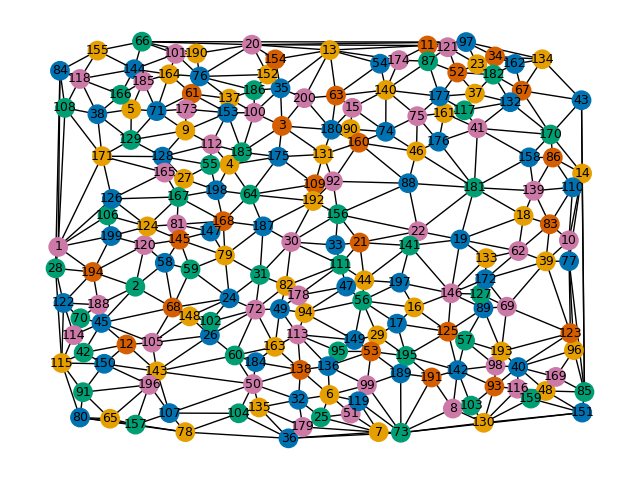

In [43]:
D200_order = {v: i for i, v in enumerate(range(200), start=1)}

draw_with_colors(D200, D200_colors, labels=D200_order, cmap = cmap, font_size=9, pos=pos, node_size=175)

In [40]:
assert all(D200_colors[v] != D200_colors[w] for v, w in D200.edges)

In [122]:
icos = nx.icosahedral_graph()

In [129]:
palette = set(range(10))
list_of_5lists  = list(combinations(palette, 5))
random_fives = {v: set(random.choice(list_of_5lists)) for v in icos.nodes}

In [153]:
icos_colors = thomassen_coloring(icos, random_fives)
#D200_colors = thomassen_coloring(D200, random_fives)

In [154]:
#assert all(icos_colors[v] != icos_colors[w] for v, w in icos.edges)
sum(icos_colors[v] == icos_colors[w] for v, w in icos.edges)

0

In [138]:
palette = set(range(10))
list_of_5lists  = list(combinations(palette, 5))
random_fives = {v: set(random.choice(list_of_5lists)) for v in D200.nodes}

In [139]:
D200_colors = thomassen_coloring(D200, random_fives)

C is: [27, 114, 79, 77, 35, 72, 150, 84, 42, 133, 96, 65, 154, 83]
C is: [83, 154, 65, 96, 133, 42, 84, 150, 72, 35, 77, 79, 114, 27]
embedding.traverse_face( 83 , 154 ) is: {154, 83, 117}
Color for 83 is {2}
Color for 154 is {1}
Starting recursion with C as: [83, 154, 65, 96, 133, 42, 84, 150, 72, 35, 77, 79, 114, 27]
C is: [83, 154, 65, 96, 133, 42, 84, 150, 72, 35, 77, 79, 114, 27]
C has length at least 4, or C has nonempty interior.
no chord
P is: [0, 193, 121]
Cnew is: [83, 154, 65, 96, 133, 42, 84, 150, 72, 35, 77, 79, 114, 121, 193, 0]
Saved colors {1, 3} for vertex 27
Discarding colors {1, 3} for vertex 0
Discarding colors {1, 3} for vertex 193
Discarding colors {1, 3} for vertex 121
Recursing with Cnew as: [83, 154, 65, 96, 133, 42, 84, 150, 72, 35, 77, 79, 114, 121, 193, 0]
C is: [83, 154, 65, 96, 133, 42, 84, 150, 72, 35, 77, 79, 114, 121, 193, 0]
C has length at least 4, or C has nonempty interior.
no chord
P is: [107, 170, 125, 105, 198]
Cnew is: [83, 154, 65, 96, 133, 42,

In [142]:
assert all(D200_colors[v] != D200_colors[w] for v, w in D200.edges)

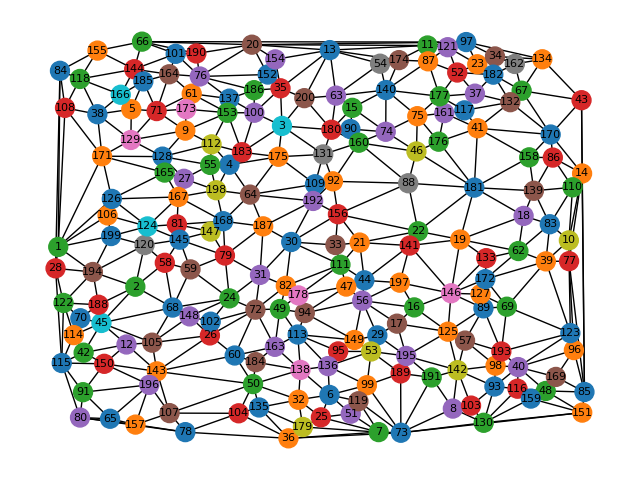

In [162]:
D200_order = {v: i for i, v in enumerate(range(200), start=1)}

draw_with_colors(D200, D200_colors, labels=D200_order, cmap = plt.cm.tab10, font_size=8, pos=pos, node_size=185)

In [86]:
octahedron = nx.octahedral_graph()

In [108]:
palette = set(range(10))
list_of_5lists  = list(combinations(palette, 5))
random_fives = {v: set(random.choice(list_of_5lists)) for v in octahedron.nodes}
random_fives

{0: {0, 2, 3, 6, 8},
 1: {0, 1, 3, 6, 9},
 2: {2, 5, 6, 7, 8},
 3: {0, 1, 2, 3, 9},
 4: {1, 2, 3, 4, 6},
 5: {1, 2, 4, 6, 8}}

In [106]:
octa_colors = thomassen_coloring(octahedron, random_fives)
#D200_colors = thomassen_coloring(D200, random_fives)
octa_colors

{0: 2, 1: 0, 2: 1, 3: 8, 4: 0, 5: 3}

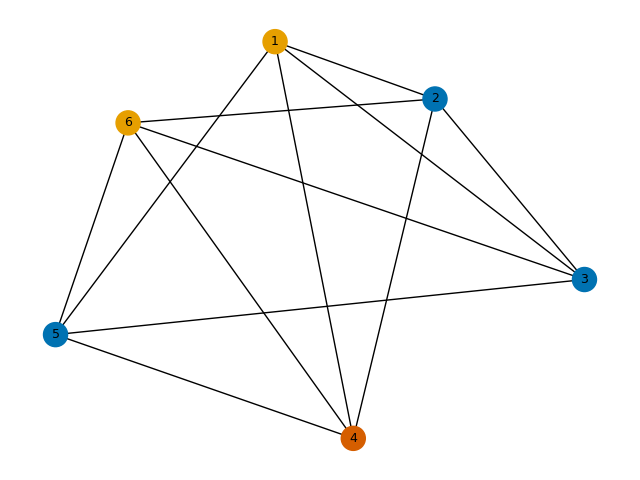

In [105]:
octa_order = {v: i for i, v in enumerate(range(6), start=1)}

draw_with_colors(octahedron, octa_colors, labels=octa_order, cmap = cmap, font_size=9, pos=nx.spring_layout(icos, seed=3))

In [155]:
palette = set(range(10))
list_of_5lists  = list(combinations(palette, 5))

In [160]:
for i in range(300):
    random_fives = {v: set(random.choice(list_of_5lists)) for v in D200.nodes}
    D200_colors = thomassen_coloring(D200, random_fives)
    assert all(D200_colors[v] != D200_colors[w] for v, w in D200.edges)

In [ ]:
def rand_lists(G, size, palette_size):
    # returns a dictionary, indexed by G.nodes, where each value is set of size [size] taken uniformly from {1,...,palette_size}.
    # maybe also palette_size is an optional argument that defaults to max(size, 10) or something
    # the reason for 10 is just that we have a nice cmap for it, plt.cm.tab10

# Packing Correspondence Colorings

The goal of this section is to extend the Thomassen 5-choosability proof to prove the following.<br>
**Thm.** Given a K5-minor-free graph G, and a correspondence assignment, **M**, G has 3 disjoint **M**-colorings.<br>

The proof is by induction on |V(G)|.  We will want a main function for the recursion: ```pack3``` and also a wrapper ```pack3_correspondence```.

We will also want a function to generate a matching for each edge.  The two obvious choices are to have all matchings be straight, and for each edge to pick a random matching.  For this, we will use the functions ```make_6matchings_straight``` and ```make_6matchings_random```.  Each of these functions takes only a graph G (nx.Graph) and returns a dictionary, indexed by G.nodes.

In [163]:
import random

In [174]:
def make_6matchings_straight(G: nx.Graph) -> dict:
    matching = {}
    for v,w in G.edges: 
        matching[v,w] = [0, 1, 2, 3, 4, 5]
        matching[w,v] = [0, 1, 2, 3, 4, 5]
    return matching

In [171]:
def make_6matchings_random(G: nx.Graph) -> dict:
    matching = {}
    for v,w in G.edges: 
        matching[v,w] = random.sample(range(6), 6) 
        matching[w,v] = [matching[v,w].index(i) for i in range(6)]
    return matching

In [172]:
icos_matchings = make_6matchings_random(icos)

In [173]:
icos_matchings

{(0, 1): [1, 2, 5, 0, 3, 4],
 (1, 0): [3, 0, 1, 4, 5, 2],
 (0, 5): [5, 2, 0, 3, 4, 1],
 (5, 0): [2, 5, 1, 3, 4, 0],
 (0, 7): [4, 0, 3, 5, 2, 1],
 (7, 0): [1, 5, 4, 2, 0, 3],
 (0, 8): [2, 4, 3, 1, 5, 0],
 (8, 0): [5, 3, 0, 2, 1, 4],
 (0, 11): [2, 5, 4, 0, 3, 1],
 (11, 0): [3, 5, 0, 4, 2, 1],
 (1, 2): [4, 5, 0, 2, 3, 1],
 (2, 1): [2, 5, 3, 4, 0, 1],
 (1, 5): [3, 5, 2, 1, 4, 0],
 (5, 1): [5, 3, 2, 0, 4, 1],
 (1, 6): [1, 4, 3, 2, 0, 5],
 (6, 1): [4, 0, 3, 2, 1, 5],
 (1, 8): [3, 0, 5, 1, 2, 4],
 (8, 1): [1, 3, 4, 0, 5, 2],
 (2, 3): [1, 5, 4, 3, 0, 2],
 (3, 2): [4, 0, 5, 3, 2, 1],
 (2, 6): [0, 5, 2, 1, 3, 4],
 (6, 2): [0, 3, 2, 4, 5, 1],
 (2, 8): [1, 5, 2, 4, 0, 3],
 (8, 2): [4, 0, 2, 5, 3, 1],
 (2, 9): [3, 4, 5, 0, 1, 2],
 (9, 2): [3, 4, 5, 0, 1, 2],
 (3, 4): [1, 4, 3, 0, 5, 2],
 (4, 3): [3, 0, 5, 2, 1, 4],
 (3, 6): [4, 0, 3, 5, 2, 1],
 (6, 3): [1, 5, 4, 2, 0, 3],
 (3, 9): [5, 4, 2, 0, 1, 3],
 (9, 3): [3, 4, 2, 5, 1, 0],
 (3, 10): [5, 4, 1, 2, 3, 0],
 (10, 3): [5, 2, 3, 4, 1, 0],
 (4, 5): [

In [ ]:
def pack3_planar_corr(
    G: nx.Graph, 
    matchings: dict,
    outer_cycle = None
) -> dict:
    start = {0, 1, 2, 3, 4, 5}  # the 6 available colors for each vertex
    lists = {v: [start.copy(), start.copy(), start.copy()] for v in G.nodes}  # make "candidate sets" for each coloring, for each vertex
    # check that the matchings for oppositely directed edges really are inverses
    assert all(matchings[v,w][matchings[w,v][i]] == i 
               for v,w in G.edges 
               for i in range(6)
              )
    
    # get embedding from networkX  (need to do something different if we later allow subgraphs of Wagner
    is_planar, embedding = nx.check_planarity(G)
    assert is_planar  # check that G really has a planar embedding

    if outer_cycle is None:  
    # find an outer cycle (boundary of 4^+-face f in embedding); assume G is near-triangulation, so only one such f exists)
        long_faces = []
        seen = set()  # so we don't re-traverse faces we've already seen 
    
        for v, w in embedding.edges:
            if (v, w) not in seen:
                temp = embedding.traverse_face(v, w, mark_half_edges=seen)
                if len(temp) >= 4:
                    long_faces.append(temp)
                
        assert len(long_faces) <= 1
        v, w = next(iter(embedding.edges))  # pick an arbitrary edge
        C = long_faces[0] if long_faces else embedding.traverse_face(v, w)  # take the long face or the 3-face on edge v,w
        #print("C is:", C)

        # get directed boundary cycle \vec{C} of f (with G on the *right* of \vec{C})
        C = list(reversed(C))  # want the outer face (f) on the *left* of C, not the right
        # specify v1, v2 as first on \vec{C}
        v1 = C[0]
        v2 = C[1]
        #print("C is:", C)
        #print("embedding.traverse_face(",v1,",",v2,") is:", set(embedding.traverse_face(v1, v2)))
    
        # we may have simpler ways to find lists[vj][i] for all vj in {v1,v2} and i in range(3); but we must do it, somehow

        for temp in permutations(range(6),3):  # look through all possible matchings from lists[v1] to range(6)
            if all(temp[i] in lists[v1][i] for i in range(3)):  # stop when we find a matching M that works
                break

        assert all(temp[i] in lists[v1][i] for i in range(3))  # check that we really did find a matching M

        for i in range(3):
            lists[v1][i] = temp[i]  # now actually use M to assign colors to lists[v1]

        for i in range(3):
            lists[v2][i].difference_update(matchings[v1,v2][lists[v1][i]])  # remove L[v1][i], now a singleton, from L[v2][i]


        for temp in permutations(range(6),3):  # look through all possible matchings from lists[v2] to range(6)
            if all(temp[i] in lists[v2][i] for i in range(3)):  # stop when we find a matching M that works
                break

        assert all(temp[i] in lists[v2][i] for i in range(3))  # check that we really did find a matching M

        for i in range(3):
            lists[v2][i] = temp[i]  # now actually use M to assign colors to lists[v2]

    else:
    # outer_cycle was specified
        assert len(outer_cycle) == 3
        v1, v2, v3 = outer_cycle
        assert len(G.nodes) > 3  # if G only has 3 nodes, then it shouldn't be its own chunk in the decomposition
        # check that G has vertices inside outer_cycle
        x = embedding.traverse_face(v3,v1)[2]
        if x == v2:  # no vertices inside outer_cycle
            outer_cycle = list(reversed(outer_cycle))  # reverse outer_cycle, since direction disagreed with embedding
        
        # now extend outer_cycle through the nbrs of v3, delete v3, remove from nbrs the colors blocked by v3, then recurse
        # use traverse_neighbors_cw(vn) and x to find P, which helps extend outer_cycle
        nbr_cycle = list(embedding.neighbors_cw_order(v3))
        nbr_cycle = nbr_cycle if nbr_cycle.index(x) == ((nbr_cycle.index(v1)+1)%len(nbr_cycle)) else list(reversed(nbr_cycle))
        assert nbr_cycle.index(x) == ((nbr_cycle.index(v1)+1)%len(nbr_cycle))  # check that nbr_cycle looks like we want it to
        a = nbr_cycle.index(v1)
        b = nbr_cycle.index(v2)
        # get the (directed) path of nbr_cycle running from v1 to v2, excluding both vertices
        # is the below indexing still right, even when len(outer_cycle)==3?
        # it should be okay, since above we have assert(len(G.nodes)) > 3
        P = nbr_cycle[a+1:b] if b > a else nbr_cycle[a+1:] + nbr_cycle[0:b]
        #print("P is:", P)
        C = outer_cycle[:-1] + list(reversed(P))
        #print("Cnew is:", Cnew)

        # math proof says to pick sets Ri of 2 safe colors in list[vn][i] (to save for v3)
        # but this is unnecessary here, because v3 already has all of its colors, so we just save those

        assert all(len(lists[v3][i]) == 1 for i in range(3))

        for i in range(3):
            for w in P:
                lists[w][i].difference_update(matchings[v3,w][lists[v3][i][0]])
                

    #print("Starting recursion with C as:", C)
    pack3_planar(G, embedding, C, matchings, lists)
    
    colorings = {v: [L[i].pop() for i in range(3)] for v, L in lists.items()}  # convert (singleton) lists to dictionary of coloring
    assert all(len(set(colorings[v])) == 3 for v in G.nodes)  # double check that every vertex gets 3 distinct colors
    assert all(matchings[v,w][colorings[v][i]] != colorings[w][i] for v,w in G.edges for i in range(3))  # and all colorings are proper
    return colorings
         

In [ ]:
def pack3_planar(
    G: nx.Graph, 
    embedding: nx.PlanarEmbedding, 
    C: list,
    matchings: dict,
    lists: dict
) -> None:
    #print("C is:", C)
    base_case = len(C) == 3  # C is short
    if base_case:
        v1, v2, v3 = C
        #print("C has length 3.")
        
    if base_case and set(embedding.traverse_face(v1, v2)) == {v1, v2, v3}:  # and C also has no verts in its interior  
        # base case of recursion; get colors for v3 and return
        # print("C has empty interior.")
        for i in range(3):
            lists[v3][i].difference_update({matchings[w,v3][lists[w][i]] for w in [v1, v2]})  
            # for each i in {0,1,2} discard from lists[v][i] colors blocked by v1 and v2

        for temp in permutations(range(6),3):  # look through all possible matchings from lists[v3] to range(6)
            if all(temp[i] in lists[v3][i] for i in range(3)):  # stop when we find a matching M that works
                break

        assert all(temp[i] in lists[v3][i] for i in range(3))  # check that we really did find a matching M

        for i in range(3):
            lists[v3][i] = temp[i]  # now actually use M to assign colors to lists[v3]
        #print("Color for", v3, "is", lists[v3])
        return
            
    else:
        # check for chords incident with vn; if such a chord exists (could be many), pick an arbitrary one; call its other endpoint vi
        #print("C has length at least 4, or C has nonempty interior.")
        vnm1, vn = C[-2:]
        v1 = C[0]
        chords = (set(C) & set(G.neighbors(vn))) - {v1, vnm1}
        vi = chords.pop() if chords else None
        #if vi:
        #    print("vi is:", vi)
        #else:
        #    print("no chord")
                           

        if vi is None:  # chord does not exist:
            x = embedding.traverse_face(vn,v1)[2]
            # use traverse_neighbors_cw(vn) and x to find P and update C (call it Cnew)
            nbr_cycle = list(embedding.neighbors_cw_order(vn))
            nbr_cycle = nbr_cycle if nbr_cycle.index(x) == ((nbr_cycle.index(v1)+1)%len(nbr_cycle)) else list(reversed(nbr_cycle))
            assert nbr_cycle.index(x) == ((nbr_cycle.index(v1)+1)%len(nbr_cycle))  # check that nbr_cycle looks like we want it to
            a = nbr_cycle.index(v1)
            b = nbr_cycle.index(vnm1)
            # get the (directed) path of nbr_cycle running from v1 to vnm1, excluding both vertices
            P = nbr_cycle[a+1:b] if b > a else nbr_cycle[a+1:] + nbr_cycle[0:b]
            #print("P is:", P)
            Cnew = C[:-1] + list(reversed(P))
            #print("Cnew is:", Cnew)

            # pick sets Ri of 2 safe colors in list[vn][i] (to save for vn)
            for i in range(3):
                lists[vn][i].difference_update({matchings[v1,vn][lists[v1][i]]})  # remove colors blocked by v1

            for temp in permutations(range(6)):
                if all(set(temp[2*i:2*i+2]) <= lists[vn][i] for i in range(3)):  # find *safe* sets R1, R2, R3
                    break

            assert all(set(temp[2*i:2*i+2]) <= lists[vn][i] for i in range(3))  # check that we really found them

            for i in range(3):
                lists[vn][i] = set(temp[2*i:2*i+2])

            for i in range(3):
                for w in P:
                    for color in lists[vn][i]:
                        lists[w][i].difference_update({matchings[vn,w][color]})

            
            #c1 = lists[vn].pop()
            #c2 = lists[vn].pop()
            #safe = {c1, c2}
            #lists[vn] = safe
            #print("Saved colors", safe,"for vertex", vn)
            # remove c1, c2 from L(w) for all w in P\setminus {v1, v{n-1}}
            # for w in P:
                #lists[w].difference_update(safe)
                #print("Discarding colors", safe, "for vertex", w)

            #print("Recursing with Cnew as:", Cnew)
            
            pack3_planar(G, embedding, Cnew, matchings, lists)
            
            #assert all(len(lists[v])==1 for v in Cnew)
            #lnew = len(Cnew)
            #assert all(lists[Cnew[i]] != lists[Cnew[(i+1)% lnew]] for i in range(lnew))
            #bad_edges = [(v, w) for v, w in G.edges if
            #             lists[v] == lists[w] and
            #             len(lists[v]) == 1]
            #assert not bad_edges, bad_edges
        
            
            # color vn from {c1,c2} \setminus L(vnm1)
            lists[vn].difference_update(lists[vnm1])
            #print("Trying to pick color for", vn)
            lists[vn] = {lists[vn].pop()}  # actually choose a color for vn
            #print("Color for", vn, "is", lists[vn])

        else:  # chord exists
            i = C.index(vi)
            C1 = C[:i+1] + [vn]
            C2 = [vn] + C[i:-1]

            #print("Recursing with C1 as:", C1)
            
            pack3_planar(G, embedding, C1, matchings, lists)
            
            assert all(len(lists[v][i]) == 1 for v in C1 for i in range(3))
            l1 = len(C1)
            assert all(lists[C1[j]][i] != lists[C1[(j+1)% l1]][i] for j in range(l1) for i in range(3))
            bad_edges = [(v, w)  
                         for v, w in G.edges
                         for i in range(3)
                         if len(lists[v][i]) == 1
                         and {matchings[v,w][next(iter(lists[v][i]))]} == lists[w][i]
                         ]
            assert not bad_edges, bad_edges
        
            #print("Recursing with C2 as:", C2)
            
            pack3_planar(G, embedding, C2, matchings, lists)
            
            #assert all(len(lists[v])==1 for v in C2)
            #l2 = len(C2)
            #assert all(lists[C2[i]] != lists[C2[(i+1)% l2]] for i in range(l2))
            #bad_edges = [(v, w) for v, w in G.edges if
            #             lists[v] == lists[w] and
            #             len(lists[v]) == 1]
            #assert not bad_edges, bad_edges